In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
  sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "clustering-data-v1"

In [2]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import clustbench

from mstcvi import treelhouette_score, plot_treelhouette, plot_scatter

In [3]:
def plot_treelhouette_summary(X, labels, *, show_mst=True, use_markers=True, point_size=20, title=None, 
                              figsize=(12, 5), M=0, **mst_euclid_kwargs):

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

  # Left
  plot_scatter(X, labels, ax=ax1, show_mst=show_mst, use_markers=use_markers,
              point_size=point_size, M=M, **mst_euclid_kwargs)
  ax1.set_title("MST partition", fontsize=11)

  # Right
  plot_treelhouette(X, labels, ax=ax2, show_cluster_scores=True, M=M, **mst_euclid_kwargs)

  content_right = 0.84

  if title:
    fig.suptitle(title, fontsize=13, x=content_right / 2, y=0.98)

  plt.tight_layout(rect=[0, 0, content_right, 0.98])

  return fig, (ax1, ax2)

Reproduction of results from the presentation "Yet another graphical aid to the interpretation and validation of cluster analysis"

**sipu/jain**

In [4]:
battery = "sipu"
dataset = "jain"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH)

In [5]:
s = silhouette_score(b.data, b.labels[0])
print(f"Silhouette score: {s:.4f}")

t = treelhouette_score(b.data, b.labels[0])
print(f"Treelhouette score: {t:.4f}")

Silhouette score: 0.4025
Treelhouette score: 0.7370


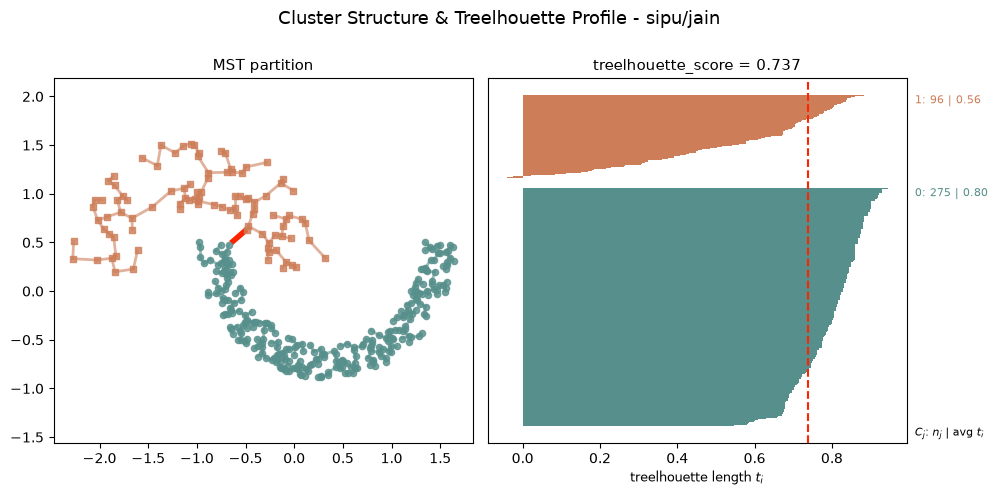

In [6]:
plot_treelhouette_summary(b.data, b.labels[0], title="Cluster Structure & Treelhouette Profile - sipu/jain");

**wut/windows**

In [7]:
battery = "wut"
dataset = "windows"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH)

In [8]:
s = silhouette_score(b.data, b.labels[0])
print(f"Silhouette score: {s:.4f}")

t = treelhouette_score(b.data, b.labels[0])
print(f"Treelhouette score: {t:.4f}")

Silhouette score: -0.1252
Treelhouette score: 0.9156


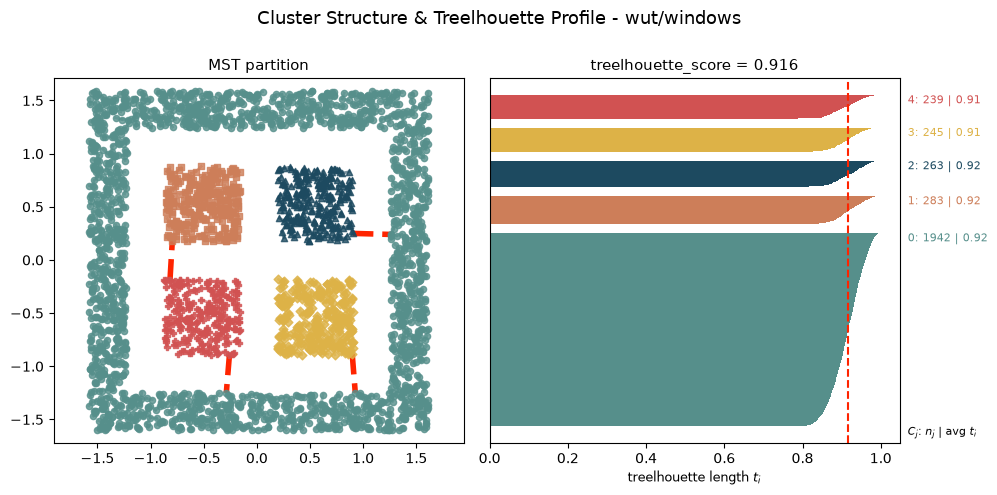

In [9]:
plot_treelhouette_summary(b.data, b.labels[0], title="Cluster Structure & Treelhouette Profile - wut/windows");

**wut/x2**

In [11]:
battery = "wut"
dataset = "x2"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH)

In [12]:
s = silhouette_score(b.data, b.labels[0])
print(f"Silhouette score: {s:.4f}")

t = treelhouette_score(b.data, b.labels[0])
print(f"Treelhouette score: {t:.4f}")

Silhouette score: 0.3566
Treelhouette score: 0.0827


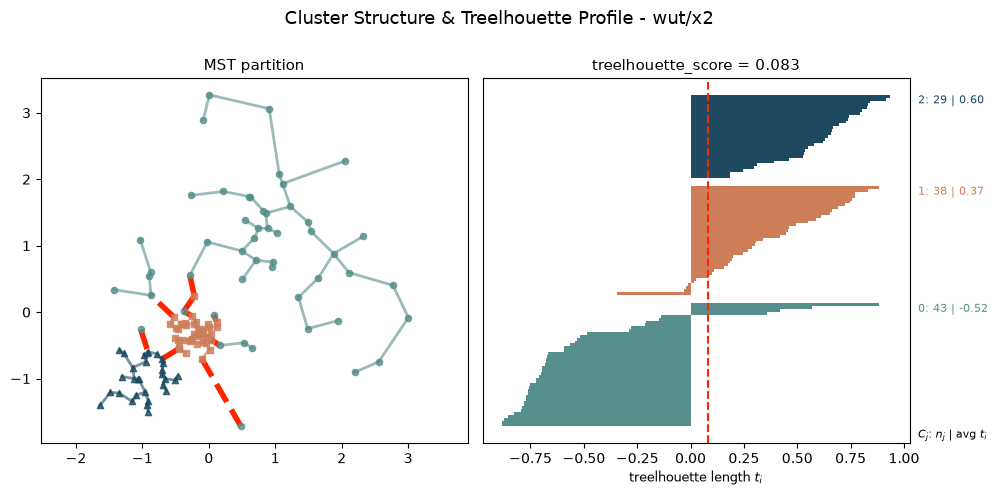

In [13]:
plot_treelhouette_summary(b.data, b.labels[0], title="Cluster Structure & Treelhouette Profile - wut/x2");

### Questions / Problems

1. Confirm that treelhouette score is calculated per edges within cluster (treelhouette score not calculated for cut edges)?

2. For cluster with one sample measure is not calculated (cluster does not have any within-cluster edges). Silhouette would give s = 0 for high score it will have negative impact, Treelhouette ignore this impact

3. **IMPORTANT** - 'for now' measure is calculated without checking MST-consistency (cluster dose not have to be created by clean cut of MST), the effect is that number of cut-edges connecting two cluster may be higher than 1 and ovearall number of cut edges will be different than [(n-1) - (k-1)] (example wut/x2). 

*"The treelhouettes work best for partitions generated by removing k − 1 edges of a
spanning tree, but the definition can naturally be extended to arbitrary clusterings.
"*

- First MST on cluster, than add k-1 "shortest" edges
- Fisrt MST on cluster, than changed definition of b instead of having cut-edges for example, similar to original Silhouette, shortest distance of u or v to another point from any other cluster?


4. Should I add experiments with M>1 (mutual reachability distance) - function include it as parameter (leave or delete)? May help with cluster singleton? 

---

#### Simplify version of experiment from "Are cluster validity measures (in) valid?"

In [4]:
from scripts.cvi_validity import generate_initial_partitions, optimize_cvi_tabu_search
from scripts.datasets import iter_benchmark_datasets

In [ ]:
battery = "wut"
for ds in iter_benchmark_datasets(["wut"], DATA_PATH=DATA_PATH):
    print(f"Battery: {ds.battery} | dataset: {ds.name} | l: {len(ds.reference_labels)} | k: {len(list(set(ds.reference_labels[0])))} | {ds.X.shape}")

**wut/mk1**

In [5]:
battery = "wut"
dataset = "mk1"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH, preprocess=True, random_state=42)

In [6]:
candidate_partitions, candidate_names = generate_initial_partitions(b.data, 3, n_init=5, random_state=42)

In [7]:
result = optimize_cvi_tabu_search(
    b.data, treelhouette_score, candidate_partitions, k=3, P=50, 
    reference_labels_list=b.labels, candidate_names=candidate_names
    )

Optimization complete!                   
    Best I(C*)         = 0.826435
    Best ARI(C*)       = 0.564899
    Candidates explored = 16
    Unique partitions visited (|T|) = 800
    Best candidate name = AC_single


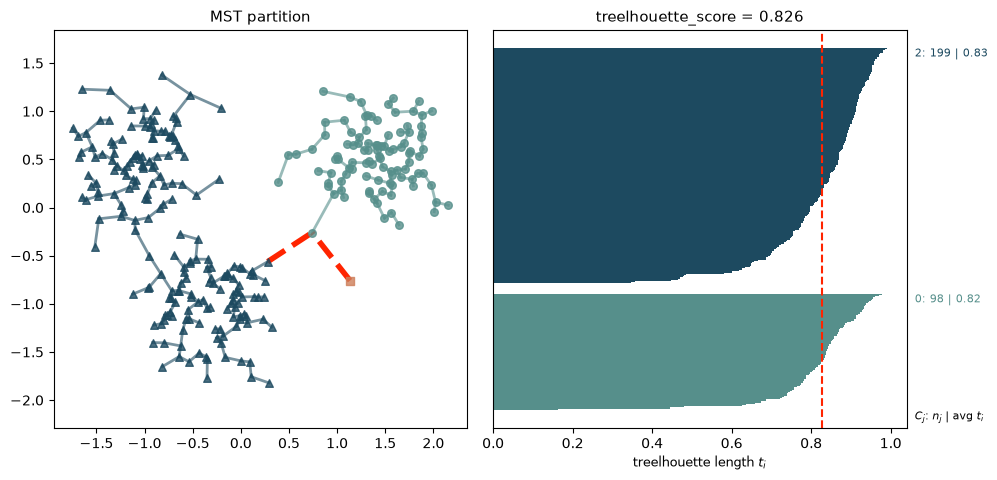

In [8]:
predicted_labels = result["best_labels"]
plot_treelhouette_summary(b.data, predicted_labels, point_size=30);

Optimization complete!                   
    Best I(C*)         = 0.892056
    Best ARI(C*)       = 1.000000
    Candidates explored = 16
    Unique partitions visited (|T|) = 800
    Best candidate name = AC_single


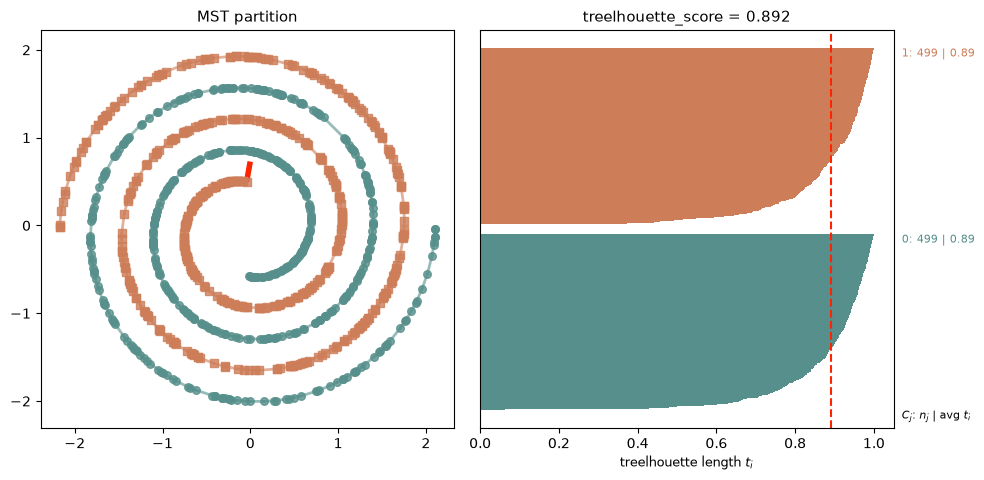

In [15]:
battery = "wut"
dataset = "mk2"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH, preprocess=True, random_state=42)
k=2

candidate_partitions, candidate_names = generate_initial_partitions(b.data, k_values=k, n_init=5, random_state=42)

result = optimize_cvi_tabu_search(
    b.data, treelhouette_score, candidate_partitions, k=k, P=50, 
    reference_labels_list=b.labels, candidate_names=candidate_names
    )

predicted_labels = result["best_labels"]
plot_treelhouette_summary(b.data, predicted_labels, point_size=30);

Optimization complete!                   
    Best I(C*)         = 0.415548
    Best ARI(C*)       = 0.005442
    Candidates explored = 16
    Unique partitions visited (|T|) = 900
    Best candidate name = AC_ward


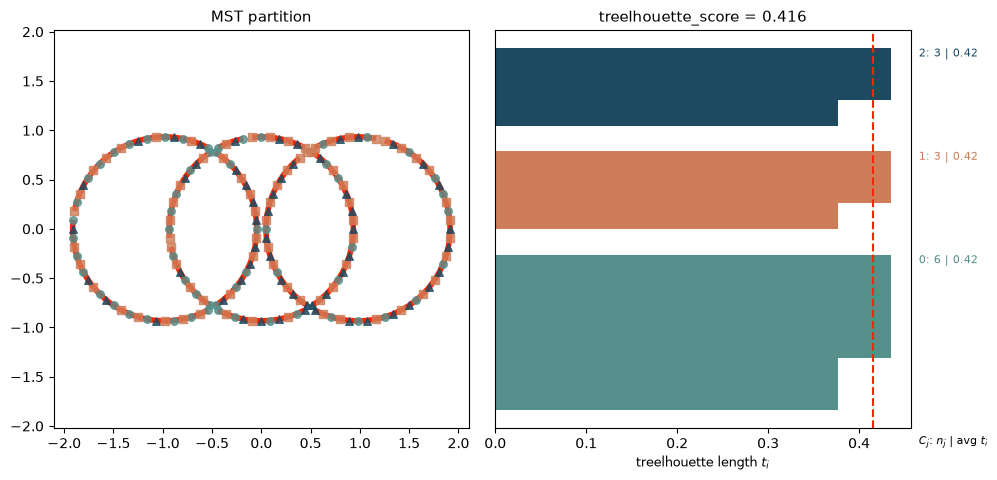

In [16]:
battery = "wut"
dataset = "z1"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH, preprocess=True, random_state=42)
k=3

candidate_partitions, candidate_names = generate_initial_partitions(b.data, k_values=k, n_init=5, random_state=42)

result = optimize_cvi_tabu_search(
    b.data, treelhouette_score, candidate_partitions, k=k, P=50, 
    reference_labels_list=b.labels, candidate_names=candidate_names
    )

predicted_labels = result["best_labels"]
plot_treelhouette_summary(b.data, predicted_labels, point_size=30);

Candidate   1/16  | Patience    1/50     

c:\Users\olenk\OneDrive\Pulpit\Master\mstcvi\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Optimization complete!                   
    Best I(C*)         = 0.855089
    Best ARI(C*)       = 0.734181
    Candidates explored = 16
    Unique partitions visited (|T|) = 802
    Best candidate name = AC_single


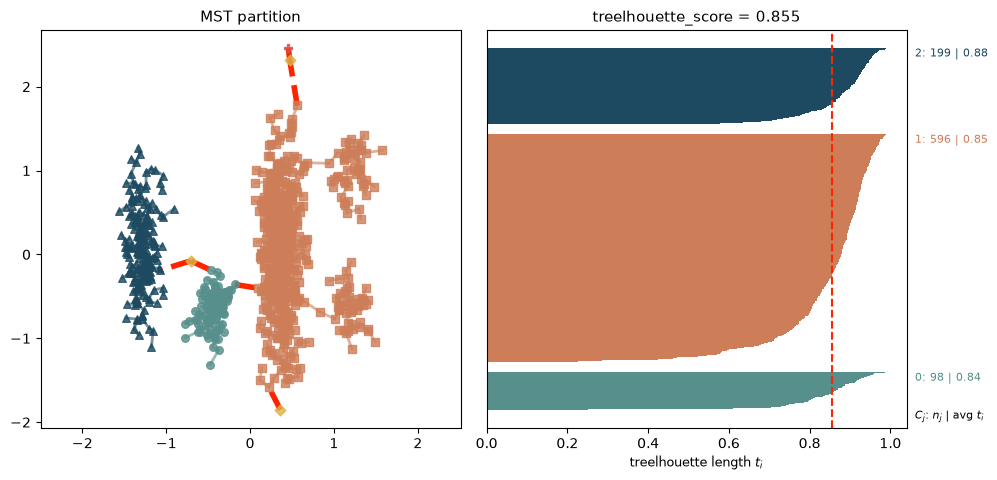

In [17]:
battery = "wut"
dataset = "z2"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH, preprocess=True, random_state=42)
k=5

candidate_partitions, candidate_names = generate_initial_partitions(b.data, k_values=k, n_init=5, random_state=42)

result = optimize_cvi_tabu_search(
    b.data, treelhouette_score, candidate_partitions, k=k, P=50, 
    reference_labels_list=b.labels, candidate_names=candidate_names
    )

predicted_labels = result["best_labels"]
plot_treelhouette_summary(b.data, predicted_labels, point_size=30);

Optimization complete!                   
    Best I(C*)         = 0.757654
    Best ARI(C*)       = 0.738692
    Candidates explored = 16
    Unique partitions visited (|T|) = 800
    Best candidate name = AC_single


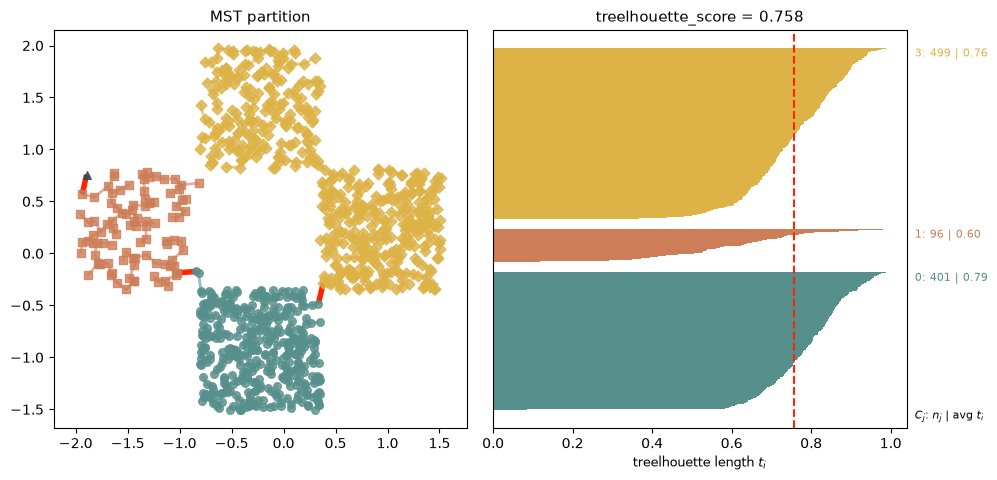

In [9]:
battery = "wut"
dataset = "z3"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH, preprocess=True, random_state=42)
k=4

candidate_partitions, candidate_names = generate_initial_partitions(b.data, k_values=k, n_init=5, random_state=42)

result = optimize_cvi_tabu_search(
    b.data, treelhouette_score, candidate_partitions, k=k, P=50, 
    reference_labels_list=b.labels, candidate_names=candidate_names
    )

predicted_labels = result["best_labels"]
plot_treelhouette_summary(b.data, predicted_labels, point_size=30);

Optimization complete!                   
    Best I(C*)         = 0.932953
    Best ARI(C*)       = 0.000150
    Candidates explored = 16
    Unique partitions visited (|T|) = 800
    Best candidate name = AC_single


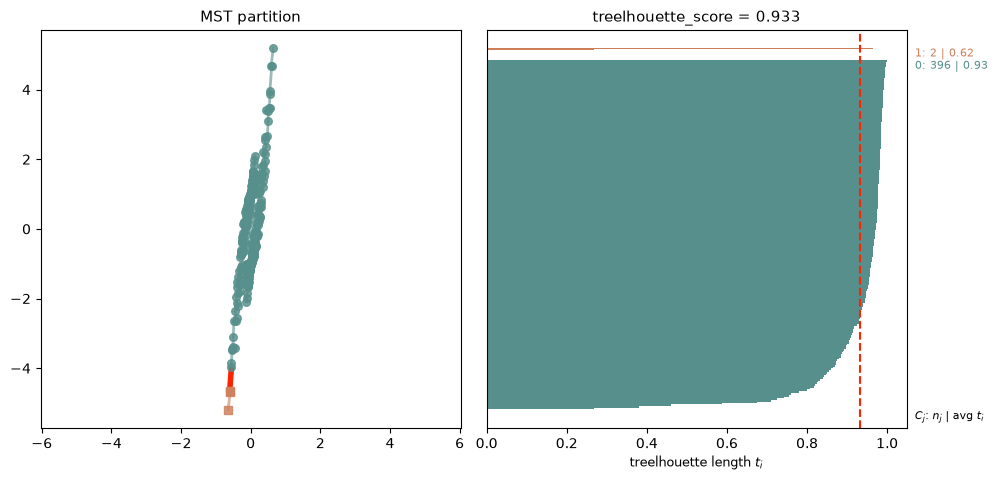

In [10]:
battery = "wut"
dataset = "twosplashes"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH, preprocess=True, random_state=42)
k=2

candidate_partitions, candidate_names = generate_initial_partitions(b.data, k_values=k, n_init=5, random_state=42)

result = optimize_cvi_tabu_search(
    b.data, treelhouette_score, candidate_partitions, k=k, P=50, 
    reference_labels_list=b.labels, candidate_names=candidate_names
    )

predicted_labels = result["best_labels"]
plot_treelhouette_summary(b.data, predicted_labels, point_size=30);

Candidate   1/16  | Patience    1/50     

c:\Users\olenk\OneDrive\Pulpit\Master\mstcvi\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Optimization complete!                   
    Best I(C*)         = 0.965509
    Best ARI(C*)       = 1.000000
    Candidates explored = 16
    Unique partitions visited (|T|) = 800
    Best candidate name = AC_single


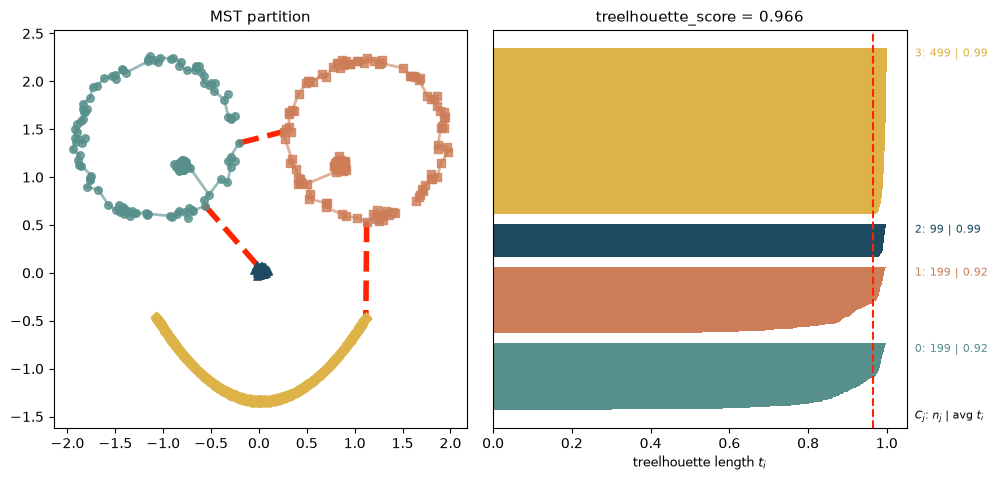

In [11]:
battery = "wut"
dataset = "smile"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH, preprocess=True, random_state=42)
k=4

candidate_partitions, candidate_names = generate_initial_partitions(b.data, k_values=k, n_init=5, random_state=42)

result = optimize_cvi_tabu_search(
    b.data, treelhouette_score, candidate_partitions, k=k, P=50, 
    reference_labels_list=b.labels, candidate_names=candidate_names
    )

predicted_labels = result["best_labels"]
plot_treelhouette_summary(b.data, predicted_labels, point_size=30);

Candidate   1/16  | Patience    1/50     

c:\Users\olenk\OneDrive\Pulpit\Master\mstcvi\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Optimization complete!                   
    Best I(C*)         = 0.953446
    Best ARI(C*)       = 1.000000
    Candidates explored = 16
    Unique partitions visited (|T|) = 800
    Best candidate name = AC_single


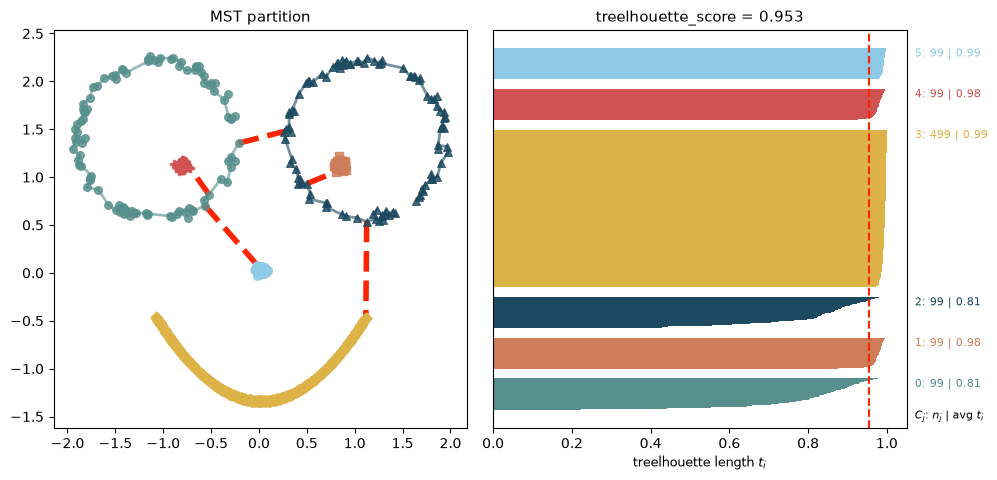

In [12]:
battery = "wut"
dataset = "smile"
b = clustbench.load_dataset(battery, dataset, path=DATA_PATH, preprocess=True, random_state=42)
k=6

candidate_partitions, candidate_names = generate_initial_partitions(b.data, k_values=k, n_init=5, random_state=42)

result = optimize_cvi_tabu_search(
    b.data, treelhouette_score, candidate_partitions, k=k, P=50, 
    reference_labels_list=b.labels, candidate_names=candidate_names
    )

predicted_labels = result["best_labels"]
plot_treelhouette_summary(b.data, predicted_labels, point_size=30);